In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')

In [29]:
sales_df = pd.read_csv("sales_data.csv")
customer_df = pd.read_csv("customer_data.csv")

In [30]:
print(sales_df.head())
print(sales_df.info())

print(customer_df.head())
print(customer_df.info())

         Date     Product  Quantity  Price Customer_ID Region  Total_Sales
0  2024-01-01       Phone         7  37300     CUST001   East       261100
1  2024-01-02  Headphones         4  15406     CUST002  North        61624
2  2024-01-03       Phone         2  21746     CUST003   West        43492
3  2024-01-04  Headphones         1  30895     CUST004   East        30895
4  2024-01-05      Laptop         8  39835     CUST005  North       318680
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Date         100 non-null    object
 1   Product      100 non-null    object
 2   Quantity     100 non-null    int64 
 3   Price        100 non-null    int64 
 4   Customer_ID  100 non-null    object
 5   Region       100 non-null    object
 6   Total_Sales  100 non-null    int64 
dtypes: int64(3), object(4)
memory usage: 5.6+ KB
None
  CustomerID  Tenure  M

In [31]:
print(sales_df.isnull().sum())
print(customer_df.isnull().sum())

Date           0
Product        0
Quantity       0
Price          0
Customer_ID    0
Region         0
Total_Sales    0
dtype: int64
CustomerID          0
Tenure              0
MonthlyCharges      0
TotalCharges        0
Contract            0
PaymentMethod       0
PaperlessBilling    0
SeniorCitizen       0
Churn               0
dtype: int64


In [32]:
sales_df.drop_duplicates(inplace=True)
customer_df.drop_duplicates(inplace=True)

In [33]:
sales_df.fillna(0, inplace=True)

In [34]:
sales_df['Date'] = pd.to_datetime(sales_df['Date'])

In [35]:
sales_df['Year'] = sales_df['Date'].dt.year
sales_df['Month'] = sales_df['Date'].dt.month
sales_df['Day'] = sales_df['Date'].dt.day

In [57]:
sales_df['Total_Sales'] = sales_df['Quantity'] * sales_df['Price']
sales_df['Customer_ID'] = sales_df['Customer_ID'].str.extract(r'(\d+)', expand=False).astype(int).apply(lambda x: f'C{x:05d}')

In [58]:
merged_df = pd.merge(
    sales_df,
    customer_df,
    left_on='Customer_ID',
    right_on='CustomerID',
    how='inner'
)

print(merged_df.head())

        Date     Product  Quantity  Price Customer_ID Region  Total_Sales  \
0 2024-01-01       Phone         7  37300      C00001   East       261100   
1 2024-01-02  Headphones         4  15406      C00002  North        61624   
2 2024-01-03       Phone         2  21746      C00003   West        43492   
3 2024-01-04  Headphones         1  30895      C00004   East        30895   
4 2024-01-05      Laptop         8  39835      C00005  North       318680   

   Year  Month  Day CustomerID  Tenure  MonthlyCharges  TotalCharges  \
0  2024      1    1     C00001       6              64          1540   
1  2024      1    2     C00002      21             113          1753   
2  2024      1    3     C00003      27              31          1455   
3  2024      1    4     C00004      53              29          7150   
4  2024      1    5     C00005      16             185          1023   

         Contract     PaymentMethod PaperlessBilling  SeniorCitizen  Churn  
0        One year       Cre

In [59]:
total_revenue = merged_df['Total_Sales'].sum()
print(total_revenue)

12365048


In [60]:
avg_order = merged_df['Total_Sales'].mean()
print(avg_order)

123650.48


In [61]:
top_customers = merged_df.groupby('CustomerID')['Total_Sales'] \
                         .sum() \
                         .sort_values(ascending=False)

print(top_customers.head(10))

CustomerID
C00016    373932
C00007    363870
C00083    350888
C00073    349510
C00020    333992
C00084    324144
C00070    318762
C00005    318680
C00065    312564
C00028    304465
Name: Total_Sales, dtype: int64


In [62]:
filtered = merged_df[
    (merged_df['Total_Sales'] > 1000) &
    (merged_df['Region'] == 'West')
]

print(filtered.head())

         Date  Product  Quantity  Price Customer_ID Region  Total_Sales  Year  \
2  2024-01-03    Phone         2  21746      C00003   West        43492  2024   
7  2024-01-08   Laptop         7   7262      C00008   West        50834  2024   
9  2024-01-10   Laptop         4  45023      C00010   West       180092  2024   
10 2024-01-11  Monitor         8   6160      C00011   West        49280  2024   
11 2024-01-12    Phone         2  13233      C00012   West        26466  2024   

    Month  Day CustomerID  Tenure  MonthlyCharges  TotalCharges  \
2       1    3     C00003      27              31          1455   
7       1    8     C00008      61             128          3088   
9       1   10     C00010      14             120          5844   
10      1   11     C00011      59              57          5168   
11      1   12     C00012       7             110          7282   

          Contract     PaymentMethod PaperlessBilling  SeniorCitizen  Churn  
2         Two year       Credit 

In [63]:
# The customer_df does not have a 'Customer_Name' column. Assuming 'CustomerID' is used for grouping or 'Tenure' is a relevant customer attribute.
# If a 'Customer_Name' was intended, it needs to be added to the customer_df or sales_df.
# For now, I'll remove the line that attempts to uppercase 'Customer_Name'.
# merged_df['Customer_Name'] = merged_df['Customer_Name'].str.upper()


In [64]:
# The customer_df does not have a 'Customer_Name' column. Assuming 'CustomerID' is used for grouping or 'Tenure' is a relevant customer attribute.
# If a 'Customer_Name' was intended, it needs to be added to the customer_df or sales_df.
# For now, I'll remove the line that attempts to strip 'Customer_Name'.
# merged_df['Customer_Name'] = merged_df['Customer_Name'].str.strip()


In [65]:
monthly_sales = merged_df.groupby('Month')['Total_Sales'].sum()

print(monthly_sales)

Month
1    4120524
2    2656050
3    4485006
4    1103468
Name: Total_Sales, dtype: int64


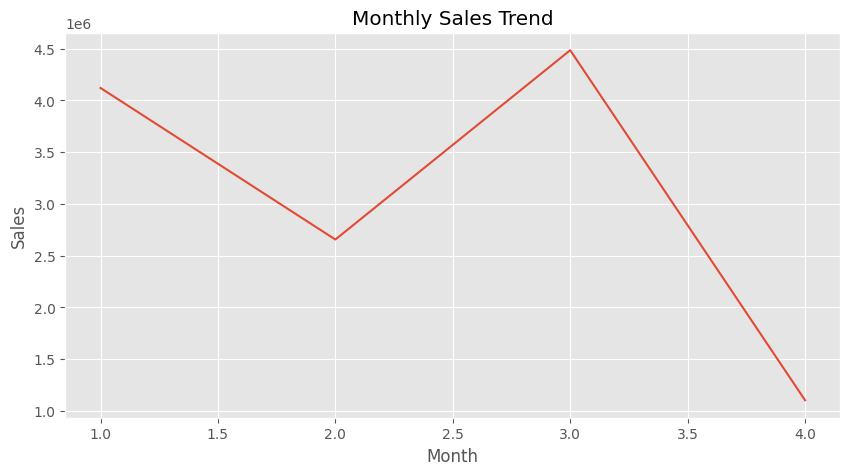

In [66]:
monthly_sales.plot(kind='line', figsize=(10,5))
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.show()

In [67]:
pivot = pd.pivot_table(
    merged_df,
    values='Total_Sales',
    index='Region',
    columns='Product',
    aggfunc='sum'
)

print(pivot)

Product  Headphones   Laptop  Monitor    Phone   Tablet
Region                                                 
East         288361   221946   642870   506828   859634
North        107091  1798206   397100   489284  1191954
South        512168  1373120    39924  1471428   341212
West         476413   495938   268177   391854   491540


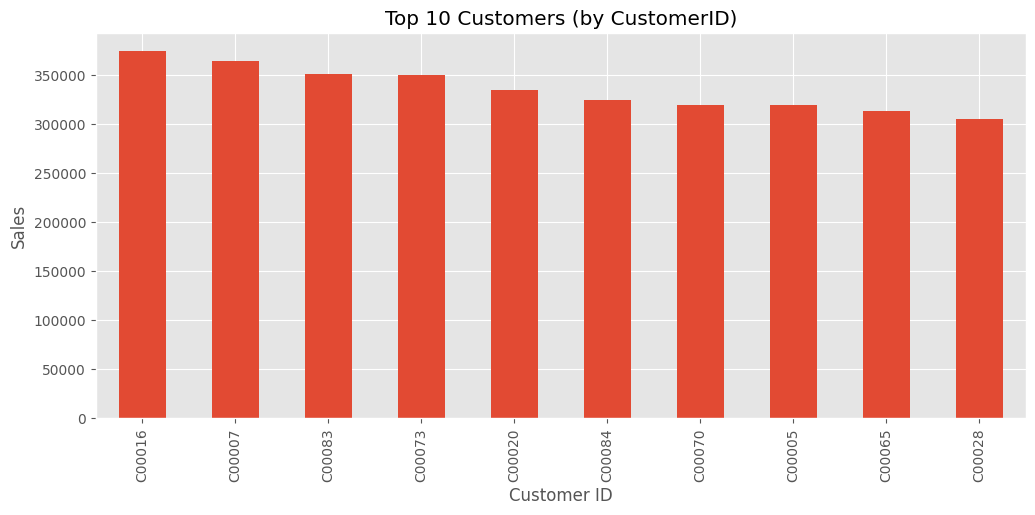

In [68]:
top_customers.head(10).plot(kind='bar', figsize=(12,5))
plt.title("Top 10 Customers (by CustomerID)")
plt.ylabel("Sales")
plt.xlabel("Customer ID")
plt.show()

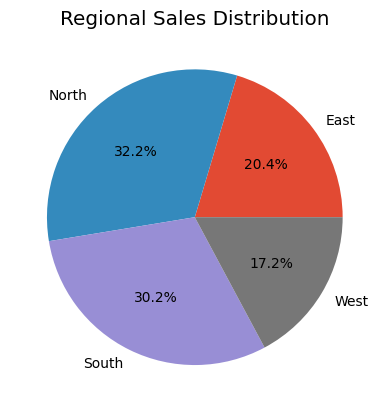

In [69]:
region_sales = merged_df.groupby('Region')['Total_Sales'].sum()

region_sales.plot(kind='pie', autopct='%1.1f%%')
plt.title("Regional Sales Distribution")
plt.ylabel("")
plt.show()

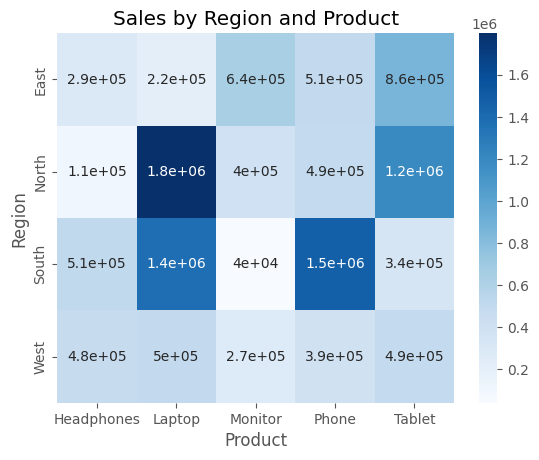

In [70]:
sns.heatmap(pivot, annot=True, cmap='Blues')

plt.title("Sales by Region and Product")
plt.show()

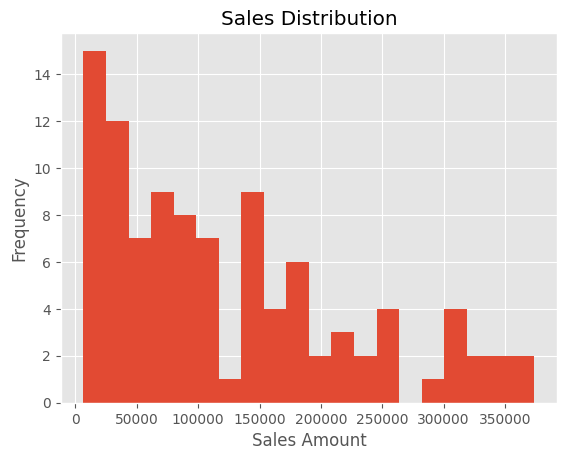

In [71]:
plt.hist(merged_df['Total_Sales'], bins=20)

plt.title("Sales Distribution")
plt.xlabel("Sales Amount")
plt.ylabel("Frequency")
plt.show()

In [72]:
print("Top Region:", region_sales.idxmax())

print("Best Customer:",
      top_customers.idxmax())

Top Region: North
Best Customer: C00016
